<a href="https://colab.research.google.com/github/wasti786/Bookworm-app/blob/main/Churn_Analysis_Forage(final)_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

client_df = pd.read_csv('/content/client_data .csv')
price_df = pd.read_csv('/content/price_data.csv')

client_df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0


In [ ]:
!pip install seaborn

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
# Load datasets
client_df = pd.read_csv('/content/client_data .csv')
price_df = pd.read_csv('/content/price_data.csv')

# Preview
client_df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0


In [ ]:
client_df.info()
price_df.info()

client_df.describe()
price_df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         

,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000
mean,0.141027,0.054630,0.030496,43.334477,10.622875,6.409984
std,0.025032,0.049924,0.036298,5.410297,12.841895,7.773592
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.125976,0.000000,0.000000,40.728885,0.000000,0.000000
50%,0.146033,0.085483,0.000000,44.266930,0.000000,0.000000
75%,0.151635,0.101673,0.072558,44.444710,24.339581,16.226389
max,0.280700,0.229788,0.114102,59.444710,36.490692,17.458221


In [ ]:
# Convert date columns
date_cols = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']

for col in date_cols:
    client_df[col] = pd.to_datetime(client_df[col], errors='coerce')

# Fill missing values
client_df.fillna(0, inplace=True)
price_df.fillna(0, inplace=True)

In [ ]:
# Aggregate price data
price_agg = price_df.groupby('id').agg({
    'price_off_peak_var': ['mean', 'std'],
    'price_peak_var': ['mean', 'std'],
    'price_mid_peak_var': ['mean', 'std']
})

price_agg.columns = ['_'.join(col) for col in price_agg.columns]
price_agg.reset_index(inplace=True)

# Merge datasets
df = pd.merge(client_df, price_agg, on='id', how='left')

# Create features
df['tenure_days'] = (df['date_end'] - df['date_activ']).dt.days
df['price_diff'] = df['price_peak_var_mean'] - df['price_off_peak_var_mean']

df.fillna(0, inplace=True)

df.head()


,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,pow_max,churn,price_off_peak_var_mean,price_off_peak_var_std,price_peak_var_mean,price_peak_var_std,price_mid_peak_var_mean,price_mid_peak_var_std,tenure_days,price_diff
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,43.648,1,0.124787,0.007829,0.100749,0.005126,0.066530,0.020983,1096,-0.024038
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,13.800,0,0.149609,0.002212,0.007124,0.024677,0.000000,0.000000,2566,-0.142485
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,13.856,0,0.170512,0.002396,0.088421,0.000506,0.000000,0.000000,2192,-0.082090
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,13.200,0,0.151210,0.002317,0.000000,0.000000,0.000000,0.000000,2192,-0.151210
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,19.800,0,0.124174,0.003847,0.103638,0.001885,0.072865,0.001588,2245,-0.020536


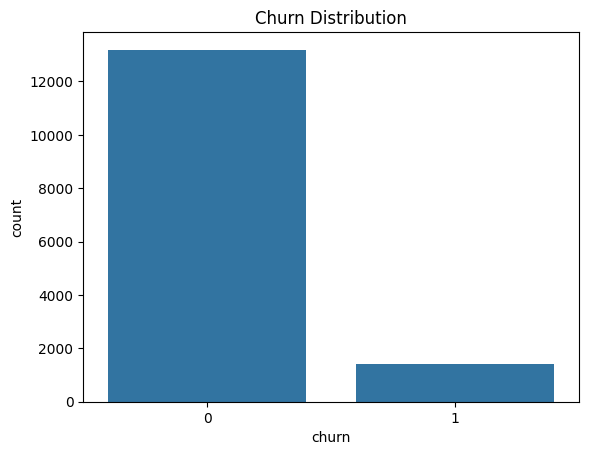

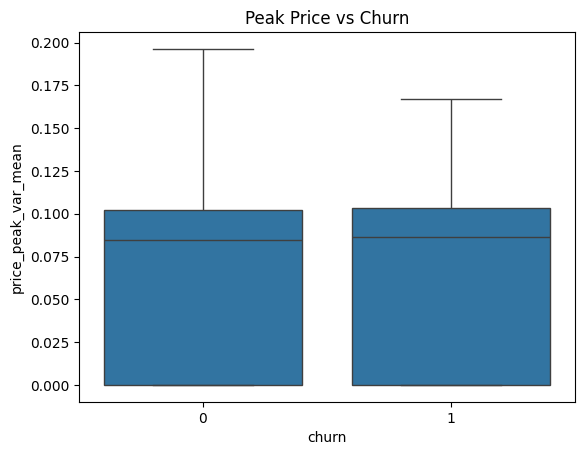

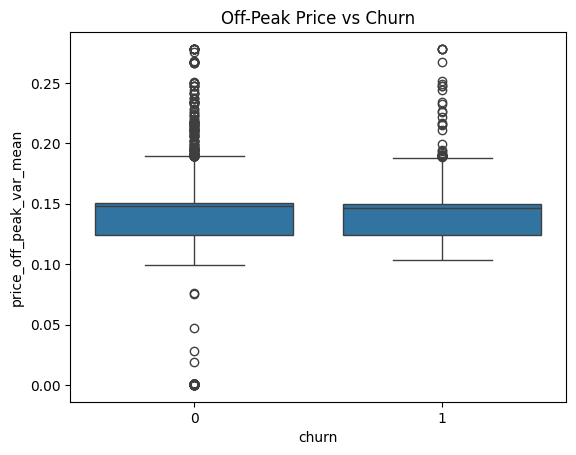

In [ ]:
# Churn distribution
sns.countplot(x='churn', data=df)
plt.title("Churn Distribution")
plt.show()

# Price vs churn
sns.boxplot(x='churn', y='price_peak_var_mean', data=df)
plt.title("Peak Price vs Churn")
plt.show()

sns.boxplot(x='churn', y='price_off_peak_var_mean', data=df)
plt.title("Off-Peak Price vs Churn")
plt.show()

In [ ]:
features = [
    'cons_12m',
    'cons_last_month',
    'net_margin',
    'num_years_antig',
    'price_peak_var_mean',
    'price_off_peak_var_mean',
    'price_diff',
    'tenure_days'
]

X = df[features]
y = df['churn']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8956194387405887

Confusion Matrix:
[[2616    1]
 [ 304    1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.94      2617
           1       0.50      0.00      0.01       305

    accuracy                           0.90      2922
   macro avg       0.70      0.50      0.48      2922
weighted avg       0.85      0.90      0.85      2922



In [ ]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.coef_[0]
}).sort_values(by='Importance', ascending=False)

importance


,Feature,Importance
2,net_margin,0.114029
4,price_peak_var_mean,0.077603
6,price_diff,0.058704
5,price_off_peak_var_mean,0.013246
0,cons_12m,-0.039069
3,num_years_antig,-0.048496
7,tenure_days,-0.262035
1,cons_last_month,-0.308472


In [ ]:
# ## Final Insights

# - Customers with higher energy prices tend to churn more.
# - Price difference between peak and off-peak impacts decisions.
# - Other important factors include:
#   - Customer tenure
#   - Consumption behavior
#   - Net margin

# ### Conclusion:
# Price is a significant factor influencing churn, but it is not the only factor.

In [ ]:
print("""
Business Recommendations:

- Offer discounts to high-risk customers
- Adjust pricing strategies before contract renewal
- Improve customer retention programs
""")


Business Recommendations:

- Offer discounts to high-risk customers
- Adjust pricing strategies before contract renewal
- Improve customer retention programs



In [ ]:
import pandas as pd

df = pd.read_csv('/content/clean_data_after_eda.csv')

df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_6m_price_off_peak_var,var_6m_price_peak_var,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,0.000131,4.100838e-05,9.084737e-04,2.086294,99.530517,44.235794,2.086425,9.953056e+01,4.423670e+01,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.000003,1.217891e-03,0.000000e+00,0.009482,0.000000,0.000000,0.009485,1.217891e-03,0.000000e+00,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.000004,9.450150e-08,0.000000e+00,0.000000,0.000000,0.000000,0.000004,9.450150e-08,0.000000e+00,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,0.000003,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000003,0.000000e+00,0.000000e+00,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,0.000011,2.896760e-06,4.860000e-10,0.000000,0.000000,0.000000,0.000011,2.896760e-06,4.860000e-10,0


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 44 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,var_6m_price_off_peak_var,var_6m_price_peak_var,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,...,14606.000000,1.460600e+04,1.460600e+04,14606.000000,14606.000000,14606.000000,14606.000000,1.460600e+04,1.460600e+04,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,1868.614880,1399.762906,0.966726,63.086871,0.137283,0.050491,43.130056,...,0.000025,3.304264e-05,1.406015e-05,0.922810,1.460247,0.634413,0.922835,1.460280e+00,6.344275e-01,0.097152
std,5.734653e+05,1.629731e+05,64364.196422,2387.571531,3247.786255,5.108289,66.165783,0.024623,0.049037,4.485988,...,0.000204,2.231791e-04,1.273170e-04,18.218286,13.760009,5.895346,18.218452,1.376010e+01,5.895470e+00,0.296175
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,494.995000,0.000000,0.000000,16.180000,0.116340,0.000000,40.606701,...,0.000003,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000004,0.000000e+00,0.000000e+00,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,1112.875000,314.000000,0.000000,18.795000,0.143166,0.084138,44.311378,...,0.000004,9.450150e-08,0.000000e+00,0.000000,0.000000,0.000000,0.000011,9.450150e-08,0.000000e+00,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,2401.790000,1745.750000,0.000000,131.030000,0.146348,0.098837,44.311378,...,0.000011,2.896760e-06,4.860000e-10,0.007962,0.000000,0.000000,0.007973,2.896760e-06,4.860000e-10,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,82902.830000,175375.000000,30.000000,599.310000,0.273963,0.195975,59.266378,...,0.005543,4.791197e-03,2.415288e-03,525.988881,399.471115,80.876029,525.994268,3.994725e+02,8.087765e+01,1.000000


In [ ]:
# Price sensitivity feature
df['price_sensitivity'] = df['var_6m_price_peak_var'] - df['var_6m_price_off_peak_var']

In [ ]:
df['consumption_diff'] = df['cons_12m'] - df['cons_last_month']

In [ ]:
df['avg_monthly_consumption'] = df['cons_12m'] / 12

In [ ]:
df['revenue_per_unit'] = df['net_margin'] / (df['cons_12m'] + 1)

In [ ]:
df['contract_duration'] = pd.to_datetime(df['date_end']) - pd.to_datetime(df['date_activ'])
df['contract_duration'] = df['contract_duration'].dt.days

In [ ]:
df['time_to_renewal'] = pd.to_datetime(df['date_renewal']) - pd.Timestamp.today()
df['time_to_renewal'] = df['time_to_renewal'].dt.days

In [ ]:
df['high_usage'] = (df['cons_12m'] > df['cons_12m'].median()).astype(int)

In [ ]:
df['profit_ratio'] = df['net_margin'] / (df['margin_gross_pow_ele'] + 1)

In [ ]:
df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_6m_price_mid_peak,churn,price_sensitivity,consumption_diff,avg_monthly_consumption,revenue_per_unit,contract_duration,time_to_renewal,high_usage,profit_ratio
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,4.423670e+01,1,-0.000090,0,0.000000,678.990000,1096,-3961,0,25.680408
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.000000e+00,0,0.001215,4660,388.333333,0.004053,2566,-3892,0,1.086881
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.000000e+00,0,-0.000003,544,45.333333,0.012110,2192,-4028,0,0.222973
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,0.000000e+00,0,-0.000003,1584,132.000000,0.016063,2192,-4045,0,0.815503
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,4.860000e-10,0,-0.000008,3899,368.750000,0.010840,2245,-4067,0,1.045088


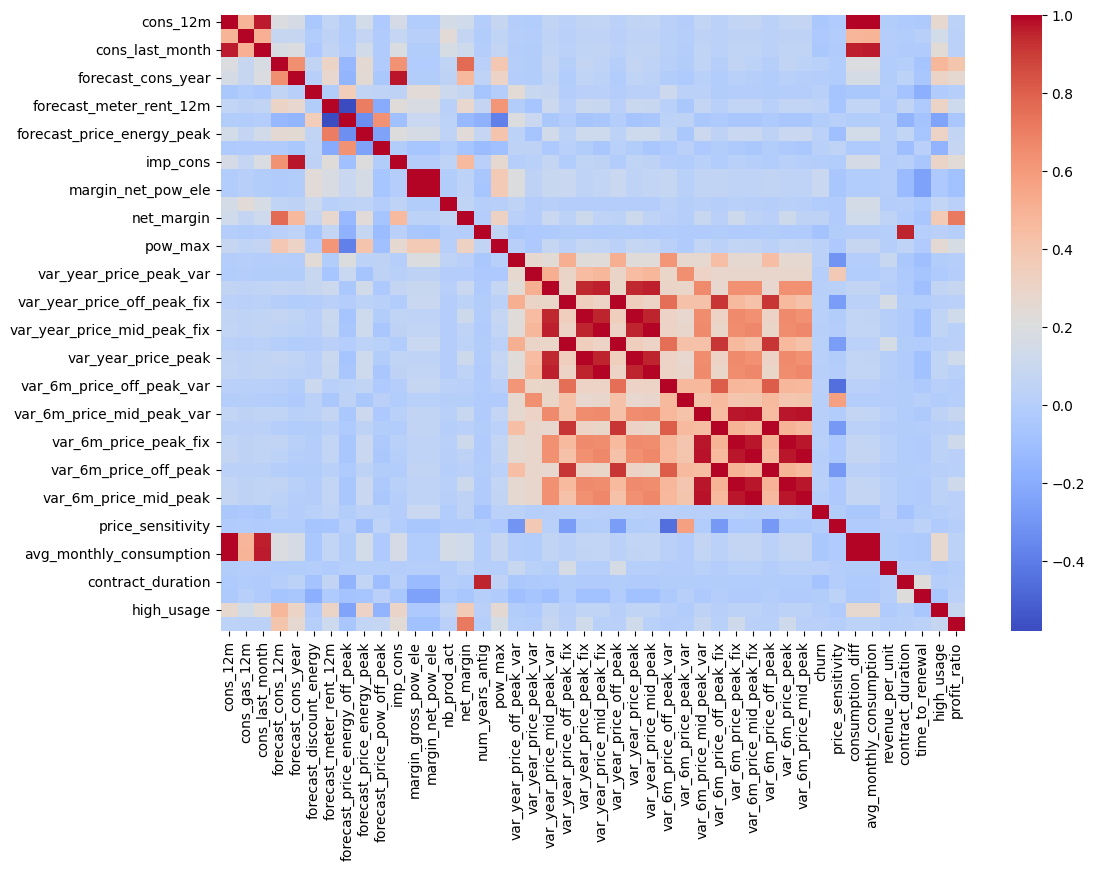

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap='coolwarm')
plt.show()

In [ ]:
df.to_csv('final_feature_engineered_data.csv', index=False)

In [ ]:
pred_df = pd.read_csv('/content/data_for_predictions.csv')
pred_df.head()

,Unnamed: 0,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,...,2,6,0,0,1,0,0,0,0,1
1,1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,...,76,4,1,0,0,0,0,1,0,0
2,2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,...,68,8,0,0,1,0,0,1,0,0
3,3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,...,69,9,0,0,0,1,0,1,0,0
4,4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,...,71,9,1,0,0,0,0,1,0,0


In [ ]:
# Price sensitivity (retained but note original features are different)
pred_df['price_sensitivity'] = pred_df['var_6m_price_peak_var'] - pred_df['var_6m_price_off_peak_var']

# Consumption features (retained)
pred_df['consumption_diff'] = pred_df['cons_12m'] - pred_df['cons_last_month']
pred_df['avg_monthly_consumption'] = pred_df['cons_12m'] / 12

# Flags (retained)
pred_df['high_usage'] = (pred_df['cons_12m'] > pred_df['cons_12m'].median()).astype(int)

# Replicating features from original training set for consistency with scaler
# Note: Using 'forecast_price_energy_peak' and 'forecast_price_energy_off_peak' as proxies for the 'mean' variants
pred_df['price_peak_var_mean'] = pred_df['forecast_price_energy_peak']
pred_df['price_off_peak_var_mean'] = pred_df['forecast_price_energy_off_peak']
# Replicate price_diff based on the new proxies
pred_df['price_diff'] = pred_df['price_peak_var_mean'] - pred_df['price_off_peak_var_mean']

# Add 'num_years_antig' to pred_df, initializing with 0 as it's not present
pred_df['num_years_antig'] = 0
# Derive tenure_days from the existing num_years_antig
pred_df['tenure_days'] = pred_df['num_years_antig'] * 365

# Fill missing (retained)
pred_df.fillna(0, inplace=True)

In [ ]:
features = [
    'cons_12m',
    'cons_last_month',
    'net_margin',
    'num_years_antig',
    'price_peak_var_mean',
    'price_off_peak_var_mean',
    'price_diff',
    'tenure_days'
]

# Ensure all features are present in pred_df, initializing if missing
# net_margin is not in data_for_predictions.csv, so initialize to 0
if 'net_margin' not in pred_df.columns:
    pred_df['net_margin'] = 0

# num_years_antig and tenure_days were supposed to be created in ytlW9bASxFVC,
# but if pred_df was reloaded or these steps didn't persist, re-create them.
if 'num_years_antig' not in pred_df.columns:
    pred_df['num_years_antig'] = 0
if 'tenure_days' not in pred_df.columns:
    pred_df['tenure_days'] = pred_df['num_years_antig'] * 365

X_pred = pred_df[features]

In [ ]:
print('Missing values in X_pred:')
print(X_pred.isnull().sum())

Missing values in X_pred:
cons_12m                   0
cons_last_month            0
net_margin                 0
num_years_antig            0
price_peak_var_mean        0
price_off_peak_var_mean    0
price_diff                 0
tenure_days                0
dtype: int64


In [ ]:
model.fit(X_train, y_train)
model.predict(X_test)

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
# Scale X_pred using the fitted scaler
X_pred_scaled = scaler.transform(X_pred)

# Make predictions
predictions_on_pred_df = model.predict(X_pred_scaled)

print("Predictions for pred_df:")
print(predictions_on_pred_df)

Predictions for pred_df:
[0 0 0 ... 0 0 0]


In [ ]:
pred_df.to_csv('churn_predictions.csv', index=False)